In [1]:
import sys
from pathlib import Path

# Specify path to scripts dir for imports
scripts_dir = Path.cwd().parent / "scripts"
sys.path.insert(0, str(scripts_dir))

In [4]:
from helper_functions import find_files

# Path to WSI root dir
# ENTER
wsi_dir = "E:/Christine/testdata"
res_dir = "E:/Christine/test_results"
suffix = ".mrxs"

slide_paths = find_files(wsi_dir, suffix)
print(f"Number of {suffix} files found: ", len(slide_paths))

Number of .mrxs files found:  2


In [5]:
import os

# Automatically generate paths
wsi_cache = os.path.join(res_dir, "cache_tissue_artifact_features.pkl")
zarr_dir = os.path.join(res_dir, "zarr")

In [6]:
from tissue_artifact_segmentation import SegmentMany

# WSI preprocessing: tissue segmentation
segmenter = SegmentMany(slide_paths, wsi_cache, zarr_dir, "tissue", version="default")

tissue segmentation:  50%|█████     | 1/2 [00:06<00:06,  6.89s/it]

Tissue processing complete for E:\Christine\test_results\zarr\CMU-1.zarr


tissue segmentation: 100%|██████████| 2/2 [00:14<00:00,  7.06s/it]

Tissue processing complete for E:\Christine\test_results\zarr\CMU-3.zarr


In [7]:
# WSI preprocessing: artifact segmentation
segmenter = SegmentMany(slide_paths, wsi_cache, zarr_dir, "artifact", version="default")

artifact segmentation:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\site-packages\lazyslide\segmentation\_artifact.py:137: UserWarning: The tiles has no overlap, using constant mode instead. Please consider rerun pp.tile_tissue to create overlapping tiles.
  warnings.warn(


GrandQC/GrandQC_MPP15_exported.pt2: reconstructing file:   0%|          |  0.00B / 33.0MB            

GrandQC/GrandQC_MPP15_exported.pt2: downloading bytes:           |  0.00B            

C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KBH Universitet\.cache\huggingface\hub\models--RendeiroLab--LazySlide-models. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
artifact segmentation:  50%|█████     | 1/2 [00:06<00:06,  6.72s/it]

Error processing CMU-1.mrxs: Error processing slide: Error during artifact segmentation: "There is no item named 'version' in the archive"


C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\site-packages\lazyslide\segmentation\_artifact.py:137: UserWarning: The tiles has no overlap, using constant mode instead. Please consider rerun pp.tile_tissue to create overlapping tiles.
  warnings.warn(
artifact segmentation: 100%|██████████| 2/2 [00:07<00:00,  3.55s/it]

Error processing CMU-3.mrxs: Error processing slide: Error during artifact segmentation: "There is no item named 'version' in the archive"


In [8]:
from feature_extraction import ExtractMany

# Feature extraction
# ENTER
foundation_model = 'h-optimus-0'

extractor = ExtractMany(wsi_paths = slide_paths, cache_path = wsi_cache, zarr_dir = zarr_dir, foundation_model = foundation_model, remove_artifacts = False, retry_on_previous_errors = False)

feature extraction progress:   0%|          | 0/2 [00:00<?, ?it/s]


Processing CMU-1.mrxs...
Using tissue key: tissue_default


Output()

C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor r

Processing complete for E:\Christine\test_results\zarr\CMU-1.zarr
Saved result for CMU-1.mrxs → E:/Christine/test_results\cache_tissue_artifact_features.pkl


...

Output()

C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
C:\Users\KBHUNI~1\anaconda3\envs\napari_env\Lib\contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor r

Processing complete for E:\Christine\test_results\zarr\CMU-3.zarr
Saved result for CMU-3.mrxs → E:/Christine/test_results\cache_tissue_artifact_features.pkl


feature extraction progress: 100%|██████████| 2/2 [09:16<00:00, 278.46s/it]


Extraction complete. Skipped 0 already-processed slides.


In [9]:
from tissue_artifact_segmentation import print_cache_summary

print_cache_summary(wsi_cache)

Total entries: 6


Processed WSIs:
artifact / default / error: Error processing slide: Error during artifact segmentation: "There is no item named 'version' in the archive": 2
features / h-optimus-0 / complete: 2
tissue / default / complete: 2


In [10]:
from abmil import ABMILInference

# Run inference with trained ABMIL
# ENTER
abmil_path = "E:/Christine/testdata/abmil.pt"
inference_cache = os.path.join(res_dir, "cache_abmil_inference.pkl")

inference = ABMILInference(checkpoint_path=abmil_path, zarr_dir=zarr_dir, slides=slide_paths, cache_path=inference_cache)
inference.process_slides()

Loaded checkpoint from E:/Christine/testdata/abmil.pt
Model config: in_dim=1536, n_classes=1, hidden_dim=256, n_heads = 4
Label mapping: {1: 0}


Running ABMIL inference...: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]

Processed 2/2 slides.
Cache saved to E:/Christine/test_results\cache_abmil_inference.pkl.


{'E:\\Christine\\testdata\\CMU-1.mrxs': {'slide_path': 'E:\\Christine\\testdata\\CMU-1.mrxs',
  'zarr_path': 'E:/Christine/test_results\\zarr\\CMU-1.zarr',
  'feature_key': 'features_h-optimus-0',
  'tile_key': 'tiles_224',
  'attention': array([[4.0116269e-05, 3.6616613e-05, 3.5990866e-05, 3.1866661e-05],
         [3.8555896e-05, 4.1783045e-05, 3.5828674e-05, 3.1481948e-05],
         [3.9740964e-05, 3.9770017e-05, 3.8011323e-05, 3.2734053e-05],
         ...,
         [3.8518261e-05, 3.9426217e-05, 3.2291555e-05, 3.3942077e-05],
         [3.8104386e-05, 3.7041456e-05, 3.5271052e-05, 3.5177505e-05],
         [3.9651317e-05, 3.7857433e-05, 3.2134267e-05, 3.1938707e-05]],
        shape=(26139, 4), dtype=float32),
  'tile_table':        tile_id  attention                                           geometry
  0            0   0.000036  POLYGON ((38704 159920, 38704 160144, 38480 16...
  1            1   0.000037  POLYGON ((38704 160144, 38704 160368, 38480 16...
  2            2   0.000038  

In [11]:
# Save inference results
inference_output = os.path.join(res_dir, "inference_result.csv")
skipped_output = os.path.join(res_dir, "inference_skipped_slides.csv")

df_inference = inference.results_dataframe()
df_inference.to_csv(inference_output, index=False)

skipped_slides = inference.get_skipped_slides()
skipped_slides.to_csv(skipped_output, index=False)
print(f"Skipped slides: {len(skipped_slides)}")

Skipped slides: 0


In [12]:
print("Number of slides with successfull inference: ", len(df_inference), "/", len(slide_paths))

Number of slides with successfull inference:  2 / 2


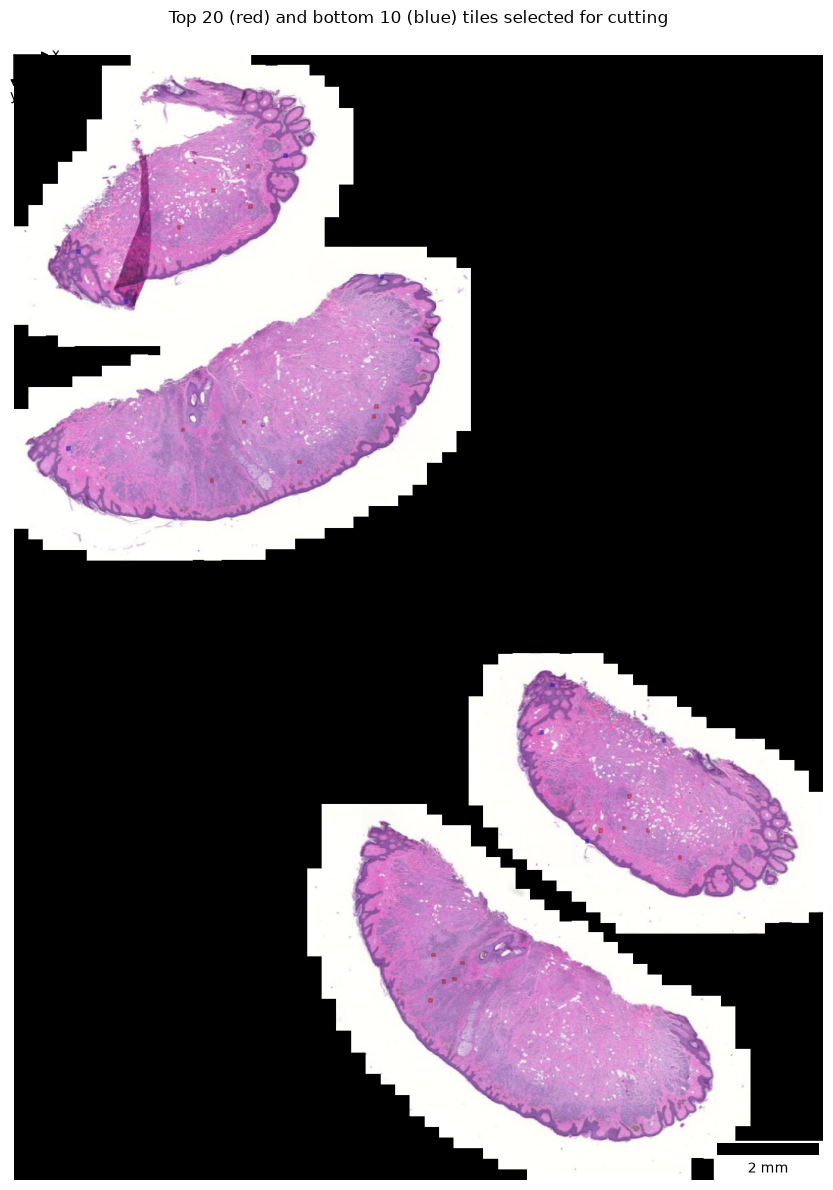

In [13]:
from roi_selection import ROISelector

slide = slide_paths[0]

selector = ROISelector(cache_path = inference_cache, slide_path = slide, top_k = 20, bottom_k = 10, top_pct = 0.10, bottom_pct = 0.10)
selector.tiles_to_cut()

In [14]:
import os

# Get top and bottom attention tiles
top_polygons, bottom_polygons = selector.viewer_polygons()

# Automatically generate files/folders for calibration points and annotations
lmd_dir = os.path.join(res_dir, "lmd")
slide_name = os.path.splitext(os.path.basename(slide))[0]
annotations_path = os.path.join(res_dir, 'annotations', f'{slide_name}_annotations.json')
screenshot_dir = os.path.join(res_dir, 'calibration_points', slide_name)

In [15]:
from interactive_viewer import launch_calibration_viewer

viewer, url = launch_calibration_viewer(
    slide_path=slide,
    top_polygons=top_polygons,
    bottom_polygons=bottom_polygons,
    save_json=annotations_path,
    screenshot_dir=screenshot_dir,
    polygon_input_order="xy",
    open_browser=True,
    internet = True
)

=== WSI calibration viewer session ===
slide_path: E:\Christine\testdata\CMU-1.mrxs
slide_dimensions: (109240, 220696)
top_polygons: 20
bottom_polygons: 10
save_json: E:\Christine\test_results\annotations\CMU-1_annotations.json
screenshot_dir: E:\Christine\test_results\calibration_points\CMU-1
internet: True
port: 52444
Viewer URL: http://127.0.0.1:52444/?session=6c1021f4e9734b7a9c10115ad3f25f01&slide=CMU-1.mrxs


127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /?session=6c1021f4e9734b7a9c10115ad3f25f01&slide=CMU-1.mrxs HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/8/0_0.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/9/0_1.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/9/0_0.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/10/0_2.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/10/0_1.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/10/1_2.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/10/1_1.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/11/1_4.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/2026 13:33:55] "GET /dzi_files/11/1_3.jpeg HTTP/1.1" 200 -
127.0.0.1 - - [04/Sep/

In [16]:
# Manually add calibration points (3 points, easy to locate on LMD)

In [18]:
# Set paths, add calibration points to sdata and write to xml for lmd
selector.set_paths(annotations_path = annotations_path, lmd_dir = lmd_dir)
sdata_lmd = selector.add_calibration_points()


# TODO: AUTOMATICALLY SAVE ATTENTION HEATMAP FOR EACH SLIDE + TILES TO CUT

# Print sdata
sdata_lmd

Set annotations path: E:/Christine/test_results\annotations\CMU-1_annotations.json
Set LMD directory: E:/Christine/test_results\lmd


SpatialData object
├── Points
│     └── 'calibration_points': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Shapes
      ├── 'bottom_tiles': GeoDataFrame shape: (10, 3) (2D shapes)
      └── 'top_tiles': GeoDataFrame shape: (20, 3) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        calibration_points (Points), bottom_tiles (Shapes), top_tiles (Shapes)

In [ ]:
selector.write_to_lmd()

In [ ]:
# TODO: Evaluate against known labels